<a href="https://colab.research.google.com/github/YURYVOM/Machine_learning_master/blob/juanmanuel%2Fproyecto-ml/proyecto_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving cs-test.csv to cs-test.csv
Saving cs-training.csv to cs-training.csv
Saving Data Dictionary.xls to Data Dictionary.xls
Saving sampleEntry.csv to sampleEntry.csv


# ***Exploración inicial***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset de entrenamiento
df = pd.read_csv('cs-training.csv', index_col=0)

# Primeras filas
print("Shape:", df.shape)
print("\nPrimeras filas:")
df.head()

Shape: (150000, 11)

Primeras filas:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


# ***Análisis detallado de las variables***

In [3]:
# Información general del dataset
print("=== SHAPE ===")
print(df.shape)

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== VALORES FALTANTES ===")
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df)) * 100
tabla_faltantes = pd.DataFrame({
    'Valores faltantes': faltantes,
    'Porcentaje %': porcentaje.round(2)
})
print(tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0])

=== SHAPE ===
(150000, 11)

=== TIPOS DE DATOS ===
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

=== VALORES FALTANTES ===
                    Valores faltantes  Porcentaje %
MonthlyIncome                   29731         19.82
NumberOfDependents               3924          2.62


In [4]:
# Imputación con mediana (más robusta que la media ante outliers)
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

# Verificar que ya no hay faltantes
print("Faltantes después de imputación:")
print(df.isnull().sum().sum())

Faltantes después de imputación:
0


/tmp/ipykernel_246/1951639728.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
/tmp/ipykernel_246/1951639728.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

Outliers extremos hasta 50,000. Lo normal debería ser entre 0 y 1 (es un porcentaje)

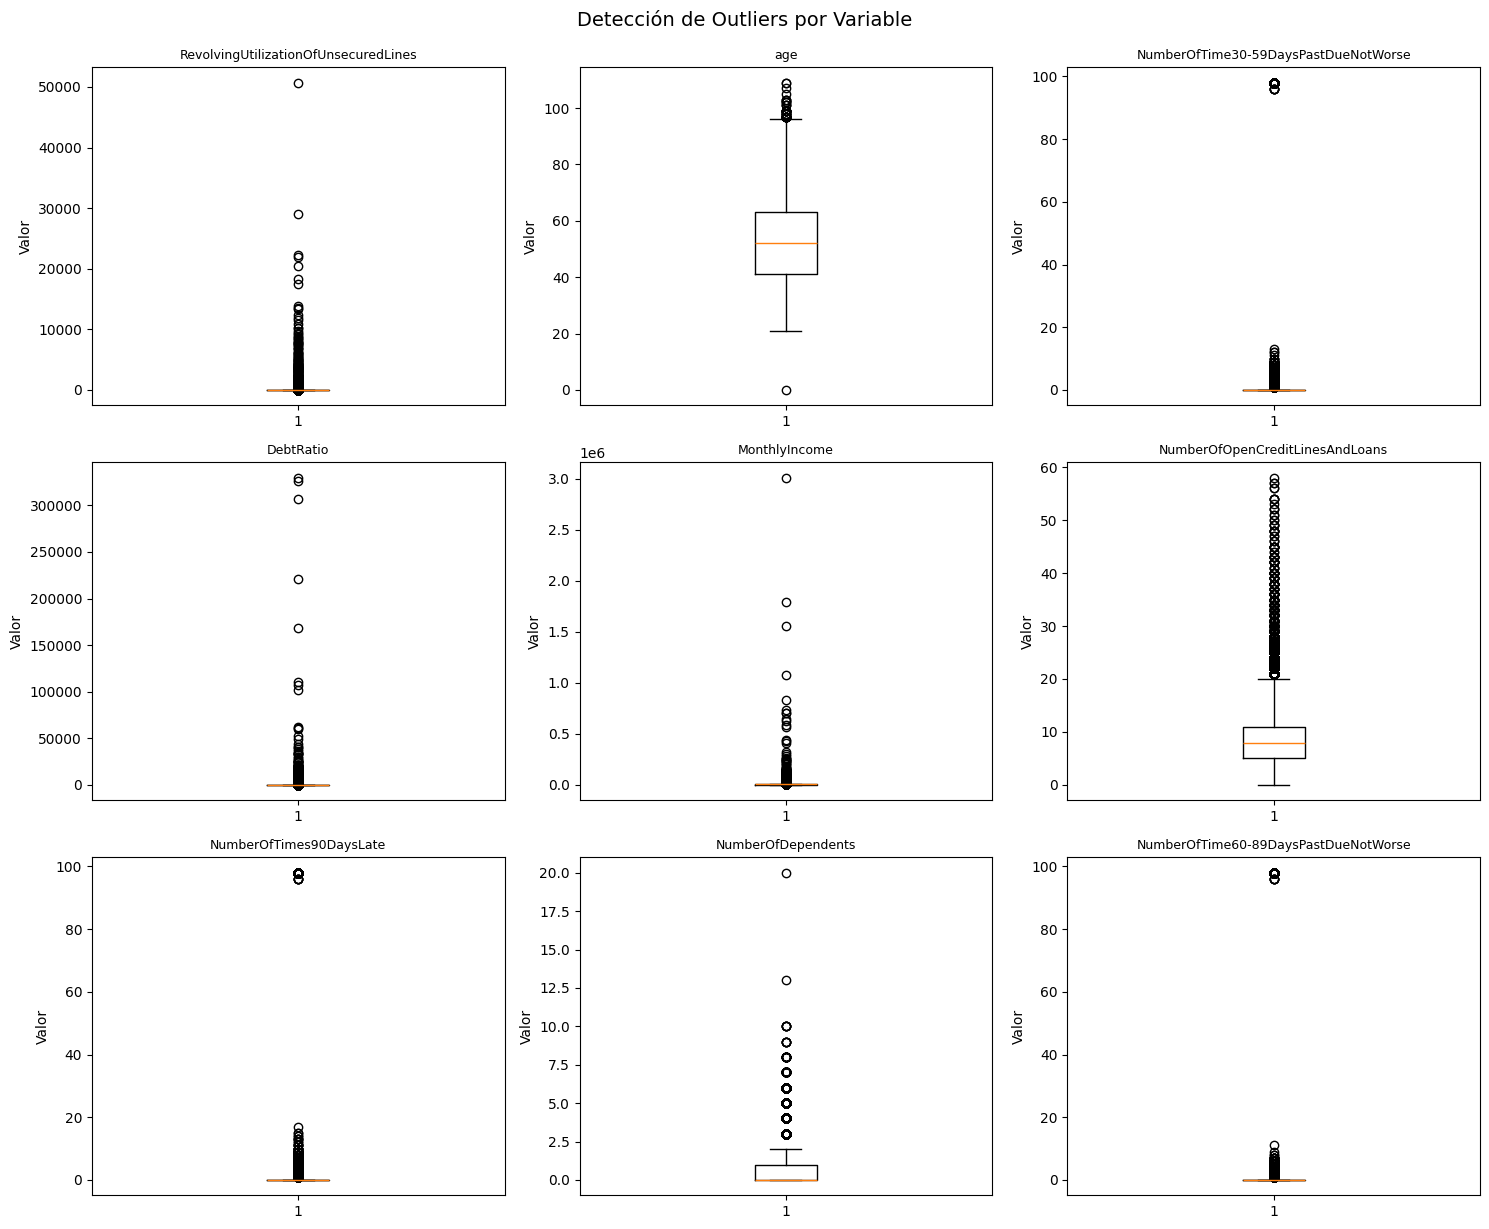

In [5]:
# boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

columnas = ['RevolvingUtilizationOfUnsecuredLines', 'age',
            'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
            'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
            'NumberOfTimes90DaysLate', 'NumberOfDependents',
            'NumberOfTime60-89DaysPastDueNotWorse']

for i, col in enumerate(columnas):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Valor')

plt.tight_layout()
plt.suptitle('Detección de Outliers por Variable',
             fontsize=14, y=1.02)
plt.show()

In [6]:
# Caps de valores extremos
# RevolvingUtilization y DebtRatio deben estar entre 0 y 1
df['RevolvingUtilizationOfUnsecuredLines'] = df['RevolvingUtilizationOfUnsecuredLines'].clip(0, 1)
df['DebtRatio'] = df['DebtRatio'].clip(0, 1)

# Valores 96, 97, 98 en variables de retrasos exceden el numero de periodos en 2 años
for col in ['NumberOfTime30-59DaysPastDueNotWorse',
            'NumberOfTimes90DaysLate',
            'NumberOfTime60-89DaysPastDueNotWorse']:
    df[col] = df[col].replace([96, 97, 98], 0)

# Age mínima razonable = 18
df['age'] = df['age'].clip(18, 100)

# MonthlyIncome cap en percentil 99
cap_income = df['MonthlyIncome'].quantile(0.99)
df['MonthlyIncome'] = df['MonthlyIncome'].clip(0, cap_income)

print("Outliers tratados correctamente")
print("\nEstadísticas después del tratamiento:")
df.describe().round(2)

Outliers tratados correctamente

Estadísticas después del tratamiento:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00
mean,0.07,0.32,52.30,0.25,0.47,6142.45,8.45,0.09,1.02,0.06,0.74
std,0.25,0.35,14.77,0.70,0.36,3835.68,5.15,0.49,1.13,0.33,1.11
min,0.00,0.00,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3903.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,7400.00,11.00,0.00,2.00,0.00,1.00
max,1.00,1.00,100.00,13.00,1.00,23000.00,58.00,17.00,54.00,11.00,20.00


Las variables más útiles para predecir incumplimiento son:

Historial de atrasos (las 3 variables de días atrasado)  el pasado predice el futuro
RevolvingUtilization  quien usa todo su crédito disponible vive al límite
Age  los jóvenes tienen más riesgo

Las variables menos útiles son DebtRatio, NumberOfDependents y MonthlyIncome — correlaciones menores a 0.10.

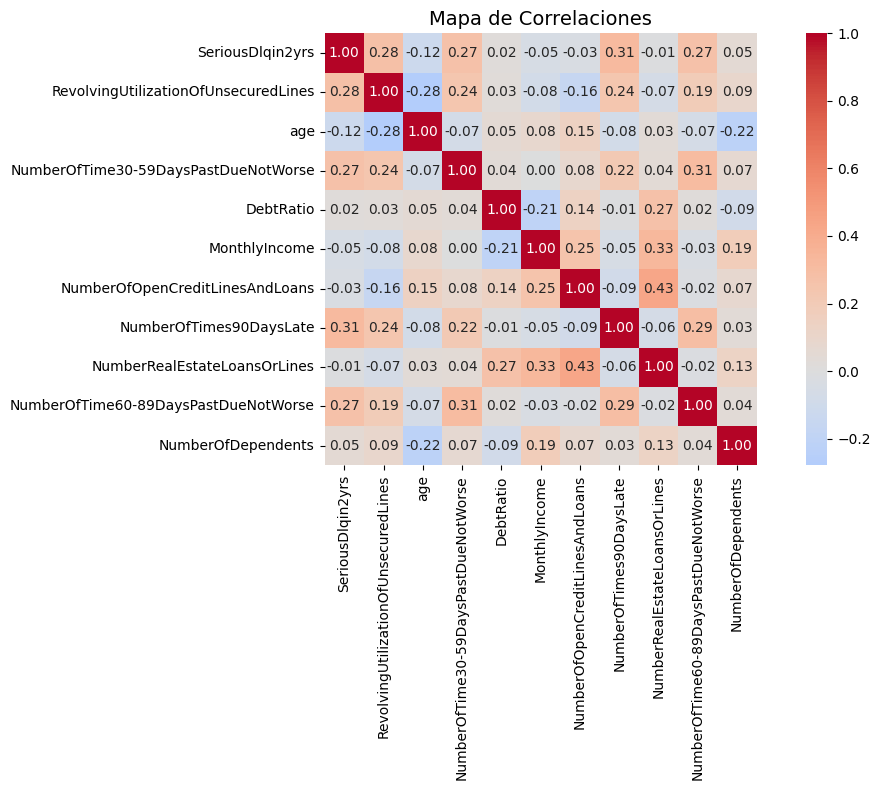


Correlación con SeriousDlqin2yrs:
SeriousDlqin2yrs                        1.000000
NumberOfTimes90DaysLate                 0.311713
RevolvingUtilizationOfUnsecuredLines    0.278096
NumberOfTime30-59DaysPastDueNotWorse    0.271411
NumberOfTime60-89DaysPastDueNotWorse    0.265594
NumberOfDependents                      0.046869
DebtRatio                               0.023156
NumberRealEstateLoansOrLines           -0.007038
NumberOfOpenCreditLinesAndLoans        -0.029669
MonthlyIncome                          -0.049790
age                                    -0.115395
Name: SeriousDlqin2yrs, dtype: float64


In [7]:
# Mapa de calor de correlaciones
plt.figure(figsize=(12, 8))
correlaciones = df.corr()

sns.heatmap(correlaciones,
            annot=True,      # muestra los números
            fmt='.2f',       # 2 decimales
            cmap='coolwarm', # azul=negativo, rojo=positivo
            center=0,
            square=True)

plt.title('Mapa de Correlaciones', fontsize=14)
plt.tight_layout()
plt.show()

# Correlaciones con la variable objetivo
print("\nCorrelación con SeriousDlqin2yrs:")
print(correlaciones['SeriousDlqin2yrs'].sort_values(ascending=False))

 Gráfico 1 — Variable Objetivo , hay desbalanceo de clases
No incumplió (0) → ~140,000 personas
Sí incumplió (1) → ~10,000 personas

 Grafico 2 - entre 30-50 años son los que más incumplen. Las personas mayores de 65 casi no incumplen. Esto confirma la correlación negativa de -0.12

 Gráfico 3 — Uso del crédito (abajo izquierda)

 La mayoría usa entre 0 y 0.4 de su crédito
Hay un pico en 1.0

Quienes usan el 100% de su crédito disponible tienen mucho más riesgo de incumplir.

El historial de atrasos es el predictor más poderoso. Si ya te atrasaste 90 días antes, es muy probable que vuelvas a incumplir

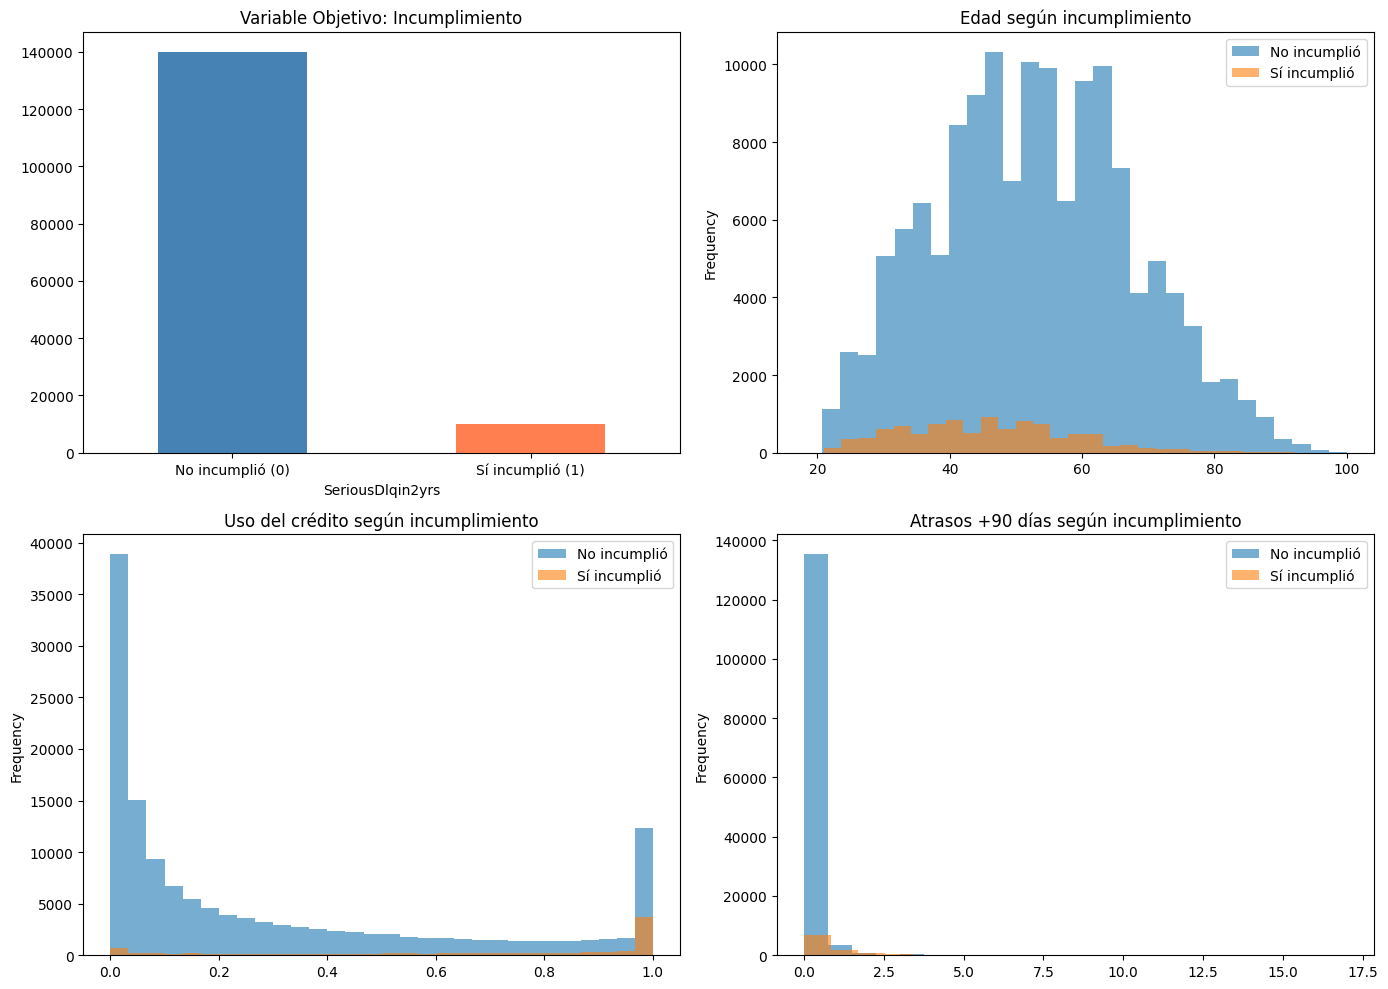

In [8]:
import matplotlib.pyplot as plt

# Distribución de las variables más correlacionadas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Variable objetivo
df['SeriousDlqin2yrs'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['steelblue','coral'])
axes[0,0].set_title('Variable Objetivo: Incumplimiento')
axes[0,0].set_xticklabels(['No incumplió (0)', 'Sí incumplió (1)'],
                           rotation=0)

# Distribución por edad
df.groupby('SeriousDlqin2yrs')['age'].plot(
    kind='hist', ax=axes[0,1], alpha=0.6, bins=30)
axes[0,1].set_title('Edad según incumplimiento')
axes[0,1].legend(['No incumplió', 'Sí incumplió'])

# Utilizacion del credito
df.groupby('SeriousDlqin2yrs')['RevolvingUtilizationOfUnsecuredLines'].plot(
    kind='hist', ax=axes[1,0], alpha=0.6, bins=30)
axes[1,0].set_title('Uso del crédito según incumplimiento')
axes[1,0].legend(['No incumplió', 'Sí incumplió'])

# Atrasos 90 dias
df.groupby('SeriousDlqin2yrs')['NumberOfTimes90DaysLate'].plot(
    kind='hist', ax=axes[1,1], alpha=0.6, bins=20)
axes[1,1].set_title('Atrasos +90 días según incumplimiento')
axes[1,1].legend(['No incumplió', 'Sí incumplió'])

plt.tight_layout()
plt.show()

## Conclusiones del EDA

1. El dataset tiene 150,000 registros y 11 variables.
2. Variables con datos faltantes: MonthlyIncome (19.82%) y
   NumberOfDependents (2.62%) — imputadas con mediana.
3. Se detectaron y trataron outliers extremos en DebtRatio,
   RevolvingUtilization y variables de atrasos.
4. El dataset está fuertemente desbalanceado: 93% no incumplió
   vs 7% sí incumplió.
5. Las variables más predictivas son el historial de atrasos
   y el uso del crédito disponible.
6. A mayor edad, menor riesgo de incumplimiento.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Separar variables predictoras (X) y variable objetivo (y)
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)
print("\nDistribución en entrenamiento:")
print(y_train.value_counts(normalize=True).round(3))

Tamaño entrenamiento: (120000, 10)
Tamaño prueba: (30000, 10)

Distribución en entrenamiento:
SeriousDlqin2yrs
0    0.933
1    0.067
Name: proportion, dtype: float64


In [10]:
# Estandarización (media=0, desviación=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Antes de escalar - Media MonthlyIncome:",
      X_train['MonthlyIncome'].mean().round(2))
print("Después de escalar - Media MonthlyIncome:",
      X_train_scaled[:, 4].mean().round(2))

Antes de escalar - Media MonthlyIncome: 6135.24
Después de escalar - Media MonthlyIncome: 0.0


In [11]:
# Modelo 1: Regresión Logística
print("=== REGRESIÓN LOGÍSTICA ===\n")

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Predicciones
y_pred_lr = lr.predict(X_test_scaled)

# Resultados
print(classification_report(y_test, y_pred_lr,
      target_names=['No incumplió', 'Sí incumplió']))

=== REGRESIÓN LOGÍSTICA ===

              precision    recall  f1-score   support

No incumplió       0.94      0.99      0.97     27995
Sí incumplió       0.63      0.16      0.26      2005

    accuracy                           0.94     30000
   macro avg       0.79      0.58      0.61     30000
weighted avg       0.92      0.94      0.92     30000



In [12]:
print("=== k-NN ===\n")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn,
      target_names=['No incumplió', 'Sí incumplió']))

=== k-NN ===

              precision    recall  f1-score   support

No incumplió       0.95      0.98      0.96     27995
Sí incumplió       0.49      0.21      0.30      2005

    accuracy                           0.93     30000
   macro avg       0.72      0.60      0.63     30000
weighted avg       0.92      0.93      0.92     30000



27801 → Dijo "no incumple" y tenía razón
  194 → Dijo "sí incumple" pero no incumplió
 1677 → Dijo "no incumple" pero SÍ incumplió  (el más grave)
  328 → Dijo "sí incumple" y tenía razón


------------------------------------------------------------------



27551 → Dijo "no incumple" y tenía razón
  444 → Dijo "sí incumple" pero no incumplió
 1580 → Dijo "no incumple" pero SÍ incumplió  (el más grave)
  425 → Dijo "sí incumple" y tenía razón

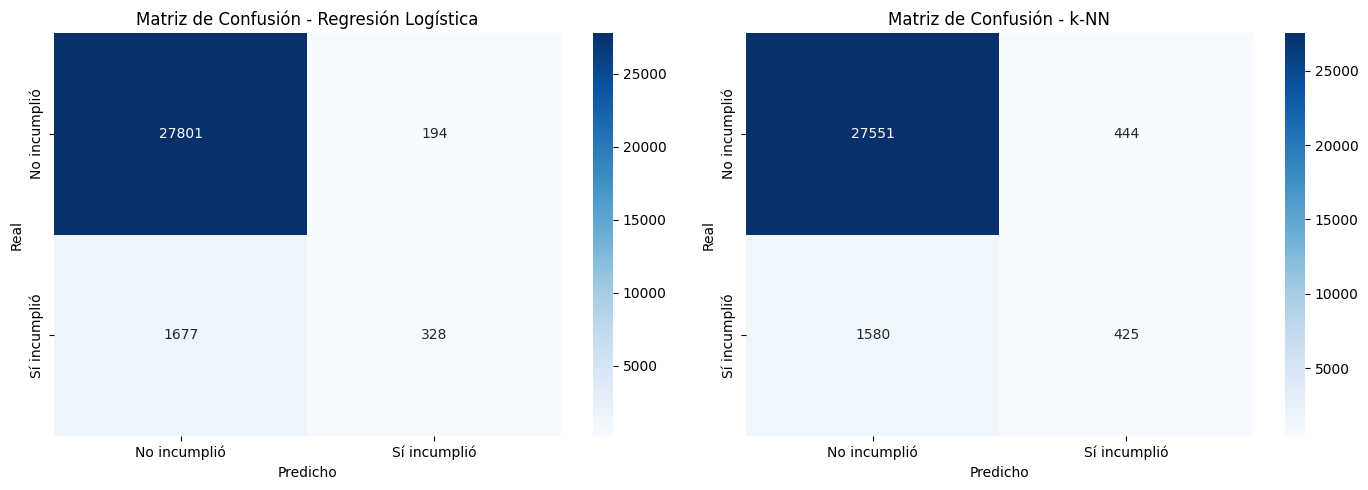


=== REGRESIÓN LOGÍSTICA ===
[[27801   194]
 [ 1677   328]]

=== k-NN ===
[[27551   444]
 [ 1580   425]]


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, titulo in zip(axes,
                               [y_pred_lr, y_pred_knn],
                               ['Regresión Logística', 'k-NN']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No incumplió', 'Sí incumplió'],
                yticklabels=['No incumplió', 'Sí incumplió'])
    ax.set_title(f'Matriz de Confusión - {titulo}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.tight_layout()
plt.show()

# Números exactos
print("\n=== REGRESIÓN LOGÍSTICA ===")
print(confusion_matrix(y_test, y_pred_lr))
print("\n=== k-NN ===")
print(confusion_matrix(y_test, y_pred_knn))

Regresión Logística es el mejor modelo porque tiene mayor AUC — significa que si ajustamos el umbral correctamente, puede detectar MÁS incumplidores que k-NN con mejor precisión.

AUC = 0.855 (Regresión Logística)
→ Si se le muestra un incumplidor y un no-incumplidor,
  el modelo los ordena correctamente el 85.5% de las veces

AUC = 0.745 (k-NN)
→ Los ordena correctamente el 74.5% de las veces

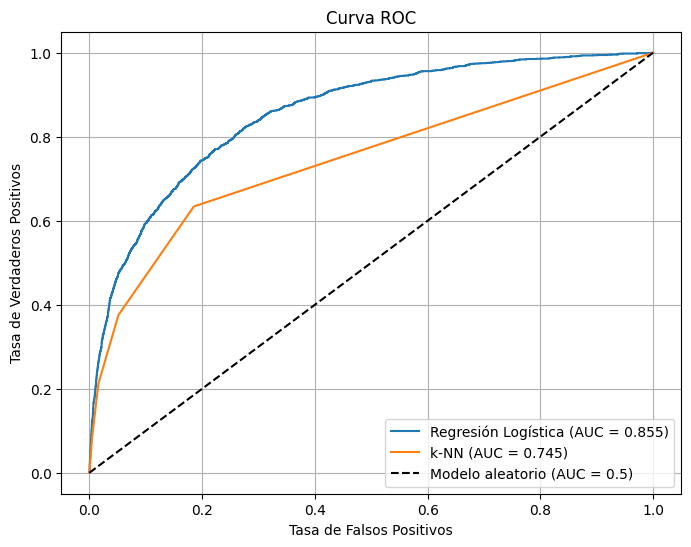

AUC Regresión Logística: 0.855
AUC k-NN: 0.745


In [14]:
from sklearn.metrics import roc_curve, auc

# Probabilidades en vez de clasificaciones
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

# Curva ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

auc_lr = auc(fpr_lr, tpr_lr)
auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Regresión Logística (AUC = {auc_lr:.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'k-NN (AUC = {auc_knn:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Modelo aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

print(f"AUC Regresión Logística: {auc_lr:.3f}")
print(f"AUC k-NN: {auc_knn:.3f}")

In [17]:
from sklearn.metrics import recall_score, precision_score

Umbral óptimo:  0.20  (no el default 0.5)
F1:             0.430 (vs 0.26 con umbral 0.5)
Recall:         0.416 (vs 0.16 con umbral 0.5)
Precisión:      0.445 (vs 0.63 con umbral 0.5)

Con umbral 0.20 el modelo detecta el 41.6% de incumplidores en vez del 16%

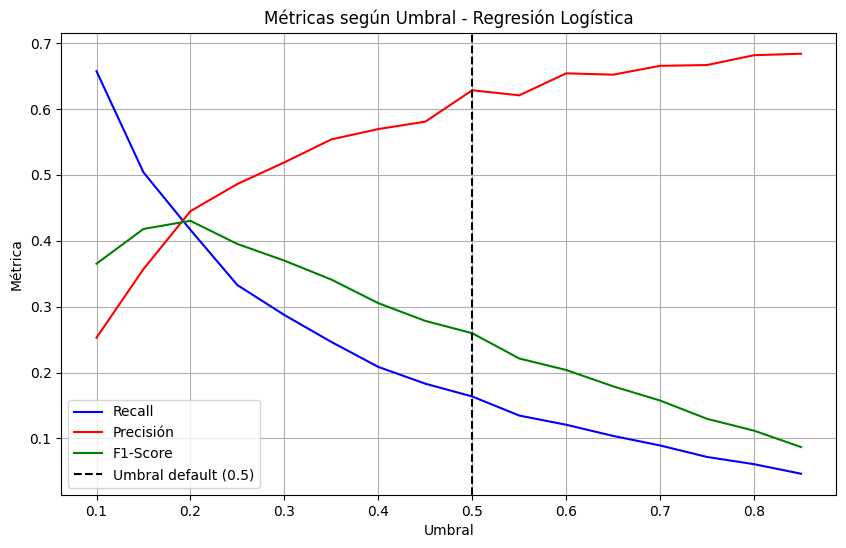

Umbral óptimo (mayor F1): 0.20
F1 en umbral óptimo: 0.430
Recall en umbral óptimo: 0.416
Precisión en umbral óptimo: 0.445


In [18]:
from sklearn.metrics import precision_recall_curve, f1_score, recall_score, precision_score
import numpy as np

# Probabilidades de la Regresión Logística (mejor AUC)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

# Probar diferentes umbrales
umbrales = np.arange(0.1, 0.9, 0.05)
recalls = []
precisiones = []
f1s = []

for umbral in umbrales:
    y_pred_umbral = (y_prob_lr >= umbral).astype(int)
    recalls.append(recall_score(y_test, y_pred_umbral))
    precisiones.append(precision_score(y_test, y_pred_umbral))
    f1s.append(f1_score(y_test, y_pred_umbral))

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(umbrales, recalls, label='Recall', color='blue')
plt.plot(umbrales, precisiones, label='Precisión', color='red')
plt.plot(umbrales, f1s, label='F1-Score', color='green')
plt.axvline(x=0.5, color='black', linestyle='--', label='Umbral default (0.5)')
plt.xlabel('Umbral')
plt.ylabel('Métrica')
plt.title('Métricas según Umbral - Regresión Logística')
plt.legend()
plt.grid(True)
plt.show()

# Umbral óptimo = mayor F1
umbral_optimo = umbrales[np.argmax(f1s)]
print(f"Umbral óptimo (mayor F1): {umbral_optimo:.2f}")
print(f"F1 en umbral óptimo: {max(f1s):.3f}")
print(f"Recall en umbral óptimo: {recalls[np.argmax(f1s)]:.3f}")
print(f"Precisión en umbral óptimo: {precisiones[np.argmax(f1s)]:.3f}")

In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Validación cruzada Regresión Logística
scores_lr = cross_val_score(lr, X_train_scaled, y_train,
                             cv=cv, scoring='roc_auc')

# Validación cruzada k-NN
scores_knn = cross_val_score(knn, X_train_scaled, y_train,
                              cv=cv, scoring='roc_auc')

print("=== VALIDACIÓN CRUZADA (5 folds) ===\n")
print("Regresión Logística:")
print(f"  AUC por fold: {scores_lr.round(3)}")
print(f"  AUC promedio: {scores_lr.mean():.3f}")
print(f"  Desviación:   {scores_lr.std():.3f}")

print("\nk-NN:")
print(f"  AUC por fold: {scores_knn.round(3)}")
print(f"  AUC promedio: {scores_knn.mean():.3f}")
print(f"  Desviación:   {scores_knn.std():.3f}")

=== VALIDACIÓN CRUZADA (5 folds) ===

Regresión Logística:
  AUC por fold: [0.851 0.841 0.848 0.847 0.853]
  AUC promedio: 0.848
  Desviación:   0.004

k-NN:
  AUC por fold: [0.74  0.735 0.733 0.736 0.743]
  AUC promedio: 0.737
  Desviación:   0.004


AUC por fold: [0.851, 0.841, 0.848, 0.847, 0.853]
AUC promedio: 0.848
Desviación:   0.004  ← muy pequeña

---------------------------------------------
AUC por fold: [0.740, 0.735, 0.733, 0.736, 0.743]
AUC promedio: 0.737
Desviación:   0.004  ← muy pequeña


el modelo es muy estable — no importa qué porción de datos use, siempre da resultados similares. Si fuera 0.05 o más, indicaría que el modelo es inestable.



In [21]:
from sklearn.model_selection import GridSearchCV

# Grid Search para Regresión Logística
print("=== GRID SEARCH - REGRESIÓN LOGÍSTICA ===")


param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print(f"Mejores parámetros: {grid_lr.best_params_}")
print(f"Mejor AUC:          {grid_lr.best_score_:.3f}")

=== GRID SEARCH - REGRESIÓN LOGÍSTICA ===
Mejores parámetros: {'C': 0.01, 'solver': 'liblinear'}
Mejor AUC:          0.849


C grande (10, 100) → modelo muy flexible
→ Se adapta mucho a los datos de entrenamiento
→ Riesgo de sobreajuste (memoriza en vez de aprender)

C pequeño (0.01) → modelo más simple y regulado
→ Aprende patrones generales
→ Funciona mejor con datos nuevos



In [23]:
print("=== GRID SEARCH - k-NN ===")
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
grid_knn.fit(X_train_scaled, y_train)

print(f"Mejores parámetros: {grid_knn.best_params_}")
print(f"Mejor AUC:          {grid_knn.best_score_:.3f}")

=== GRID SEARCH - k-NN ===
Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Mejor AUC:          0.806


Modelo                AUC sin optimizar   /-/   AUC con Grid Search

Regresión Logística       0.855                       0.849

k-NN0                    0.7450                       0.806


La Regresión Logística sigue siendo el mejor modelo, pero k-NN mejoró bastante con la optimización.